In [1]:
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 71.0 MB/s eta 0:00:00


In [2]:
import gurobipy as gp
import numpy as np


distance = np.array([
    [0, 15, 0, 0, 24, 0, 18, 0, 0, 0, 0, 0],
    [15, 0, 22, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 22, 0, 18, 16, 0, 0, 0, 20, 0, 0, 0],
    [0, 0, 18, 0, 0, 12, 0, 0, 0, 0, 0, 0],
    [24, 0, 16, 0, 0, 0, 25, 12, 24, 0, 0, 0],
    [0, 0, 0, 12, 0, 0, 0, 0, 12, 0, 0, 22],
    [18, 0, 0, 0, 25, 0, 0, 15, 0, 22, 0, 0],
    [0, 0, 0, 0, 12, 0, 15, 0, 30, 0, 25, 0],
    [0, 0, 20, 0, 24, 12, 0, 30, 0, 0, 19, 19],
    [0, 0, 0, 0, 0, 0, 22, 0, 0, 0, 19, 0],
    [0, 0, 0, 0, 0, 0, 0, 25, 19, 19, 0, 21],
    [0, 0, 0, 0, 0, 22, 0, 0, 19, 0, 21, 0]
])

In [3]:
import numpy as np
import networkx as nx

import gurobipy as gp
import numpy as np


distance = np.array([
    [0, 15, 0, 0, 24, 0, 18, 0, 0, 0, 0, 0],
    [15, 0, 22, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 22, 0, 18, 16, 0, 0, 0, 20, 0, 0, 0],
    [0, 0, 18, 0, 0, 12, 0, 0, 0, 0, 0, 0],
    [24, 0, 16, 0, 0, 0, 25, 12, 24, 0, 0, 0],
    [0, 0, 0, 12, 0, 0, 0, 0, 12, 0, 0, 22],
    [18, 0, 0, 0, 25, 0, 0, 15, 0, 22, 0, 0],
    [0, 0, 0, 0, 12, 0, 15, 0, 30, 0, 25, 0],
    [0, 0, 20, 0, 24, 12, 0, 30, 0, 0, 19, 19],
    [0, 0, 0, 0, 0, 0, 22, 0, 0, 0, 19, 0],
    [0, 0, 0, 0, 0, 0, 0, 25, 19, 19, 0, 21],
    [0, 0, 0, 0, 0, 22, 0, 0, 19, 0, 21, 0]
])

def djikstra(distance_matrix):
    num_nodes = distance_matrix.shape[0]

    # Build the graph
    G = nx.Graph()
    for i in range(num_nodes):
        for j in range(num_nodes):
            if distance_matrix[i, j] > 0 and i != j:
                G.add_edge(i, j, weight=distance_matrix[i, j])

    # Compute all-pairs shortest path lengths and paths
    all_pairs_dist = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))
    all_pairs_paths = dict(nx.all_pairs_dijkstra_path(G, weight='weight'))

    # Initialize distance matrix
    full_distance = np.full((num_nodes, num_nodes), 9999.0)
    full_paths = [[[] for _ in range(num_nodes)] for _ in range(num_nodes)]

    for start_node, distances in all_pairs_dist.items():
        for end_node, dist in distances.items():
            full_distance[start_node, end_node] = dist
            full_paths[start_node][end_node] = all_pairs_paths[start_node][end_node]

    # Self-loops: distance = 0, path = [node]
    np.fill_diagonal(full_distance, 0.0)
    for i in range(num_nodes):
        full_paths[i][i] = [i]

    return full_distance, full_paths


num_nodes = distance.shape[0]
full_distance, full_paths = djikstra(distance)

print("Node-to-Node Shortest Distance Matrix:")
print(full_distance)

Node-to-Node Shortest Distance Matrix:
[[ 0. 15. 37. 55. 24. 60. 18. 33. 48. 40. 58. 67.]
 [15.  0. 22. 40. 38. 52. 33. 48. 42. 55. 61. 61.]
 [37. 22.  0. 18. 16. 30. 41. 28. 20. 58. 39. 39.]
 [55. 40. 18.  0. 34. 12. 59. 46. 24. 62. 43. 34.]
 [24. 38. 16. 34.  0. 36. 25. 12. 24. 47. 37. 43.]
 [60. 52. 30. 12. 36.  0. 57. 42. 12. 50. 31. 22.]
 [18. 33. 41. 59. 25. 57.  0. 15. 45. 22. 40. 61.]
 [33. 48. 28. 46. 12. 42. 15.  0. 30. 37. 25. 46.]
 [48. 42. 20. 24. 24. 12. 45. 30.  0. 38. 19. 19.]
 [40. 55. 58. 62. 47. 50. 22. 37. 38.  0. 19. 40.]
 [58. 61. 39. 43. 37. 31. 40. 25. 19. 19.  0. 21.]
 [67. 61. 39. 34. 43. 22. 61. 46. 19. 40. 21.  0.]]


In [9]:
import gurobipy as gp
from gurobipy import GRB


def solve_technician_routing(
    all_nodes,
    farmers,
    technicians,
    office_node,
    initial_straws,
    total_straws_available,
    full_distance,
    origin_of,
    time_limit=None,
    verbose=False
):

    # -----------------------------
    # PREPROCESSING
    # -----------------------------
    all_nodes = sorted(set(all_nodes))
    farmers = sorted(set(farmers))

    index_map = {node: idx for idx, node in enumerate(all_nodes)}
    N = len(all_nodes)
    big_M = 10**6

    m = gp.Model("ConnectedTechnicianRouting")

    if time_limit is not None:
        m.Params.TimeLimit = time_limit
    if verbose:
        m.Params.OutputFlag = 1

    # -----------------------------
    # DECISION VARIABLES
    # -----------------------------
    x = m.addVars(all_nodes, all_nodes, technicians,
                  vtype=GRB.BINARY, name="x")

    r = m.addVars(all_nodes, technicians,
                  lb=0, ub=10,
                  vtype=GRB.INTEGER, name="r")

    RA = m.addVars(technicians,
                   lb=0, ub=total_straws_available,
                   vtype=GRB.INTEGER, name="RA")

    # visit indicator
    y = m.addVars(all_nodes, technicians,
                  vtype=GRB.BINARY, name="y")

    # flow variable (SCF)
    f = m.addVars(all_nodes, all_nodes, technicians,
                  lb=0, ub=N,
                  vtype=GRB.CONTINUOUS, name="flow")

    # -----------------------------
    # DISTANCE FUNCTION
    # -----------------------------
    def dist(i, j):
        if isinstance(full_distance, dict):
            return full_distance[i][j]
        return full_distance[index_map[i]][index_map[j]]

    # -----------------------------
    # OBJECTIVE
    # -----------------------------
    m.setObjective(
        gp.quicksum(
            dist(i, j) * x[i, j, t]
            for t in technicians
            for i in all_nodes
            for j in all_nodes
            if i != j
        ),
        GRB.MINIMIZE
    )

    # -----------------------------
    # 1. START / END DEPOT CONSTRAINTS
    # -----------------------------
    for t in technicians:
        origin = origin_of[t]

        m.addConstr(
            gp.quicksum(x[origin, j, t] for j in all_nodes if j != origin) == 1,
            name=f"Start_{t}"
        )

        m.addConstr(
            gp.quicksum(x[i, origin, t] for i in all_nodes if i != origin) == 1,
            name=f"Return_{t}"
        )

    # -----------------------------
    # 2. FLOW CONSERVATION
    # -----------------------------
    for t in technicians:
        for j in all_nodes:

            m.addConstr(
                gp.quicksum(x[i, j, t] for i in all_nodes if i != j)
                ==
                gp.quicksum(x[j, k, t] for k in all_nodes if k != j),
                name=f"Flow_{j}_{t}"
            )

    # -----------------------------
    # 3. VISIT LINKING (x ↔ y)
    # -----------------------------
    for t in technicians:
        for i in all_nodes:

            m.addConstr(
                gp.quicksum(x[j, i, t] for j in all_nodes if j != i) == y[i, t],
                name=f"VisitIn_{i}_{t}"
            )

    # depot always visited
    for t in technicians:
        m.addConstr(y[origin_of[t], t] == 1)

    # each farmer visited exactly once
    for f_node in farmers:
        m.addConstr(
            gp.quicksum(y[f_node, t] for t in technicians) == 1,
            name=f"VisitOnce_{f_node}"
        )

    # -----------------------------
    # 4. SINGLE-COMMODITY FLOW
    # -----------------------------
    for t in technicians:
        origin = origin_of[t]

        for i in all_nodes:
            for j in all_nodes:
                if i != j:
                    m.addConstr(
                        f[i, j, t] <= N * x[i, j, t],
                        name=f"FlowLink_{i}_{j}_{t}"
                    )

        # depot supplies flow = number of visited nodes
        m.addConstr(
            gp.quicksum(f[origin, j, t] for j in all_nodes if j != origin)
            -
            gp.quicksum(f[i, origin, t] for i in all_nodes if i != origin)
            ==
            gp.quicksum(y[i, t] for i in all_nodes if i != origin),
            name=f"FlowDepot_{t}"
        )

        # flow conservation at visited nodes
        for k in all_nodes:
            if k == origin:
                continue

            m.addConstr(
                gp.quicksum(f[i, k, t] for i in all_nodes if i != k)
                -
                gp.quicksum(f[k, j, t] for j in all_nodes if j != k)
                ==
                y[k, t],
                name=f"FlowCons_{k}_{t}"
            )

    # -----------------------------
    # 5. STRAW INVENTORY SYSTEM
    # -----------------------------
    for t in technicians:
        origin = origin_of[t]

        m.addConstr(r[origin, t] == initial_straws[t],
                    name=f"InitStraw_{t}")

        for i in all_nodes:
            for j in all_nodes:
                if i == j:
                    continue

                # visit farmer → consume 1 straw
                if j in farmers:
                    m.addConstr(
                        r[j, t] >= r[i, t] - 1 - big_M * (1 - x[i, j, t])
                    )
                    m.addConstr(
                        r[j, t] <= r[i, t] - 1 + big_M * (1 - x[i, j, t])
                    )

                # visit office → refill
                if j == office_node:
                    m.addConstr(
                        r[j, t] >= r[i, t] + RA[t] - big_M * (1 - x[i, j, t])
                    )
                    m.addConstr(
                        r[j, t] <= r[i, t] + RA[t] + big_M * (1 - x[i, j, t])
                    )

    # global straw limit
    m.addConstr(
        gp.quicksum(RA[t] for t in technicians) <= total_straws_available,
        name="GlobalStrawLimit"
    )

    # must have straw to serve farmers
    for t in technicians:
        for i in all_nodes:
            m.addConstr(
                gp.quicksum(x[i, j, t] for j in farmers if j != i)
                <= r[i, t]
            )

    # -----------------------------
    # SOLVE
    # -----------------------------
    m.optimize()

    # -----------------------------
    # ROUTE RECONSTRUCTION
    # -----------------------------
    routes = {}

    if m.SolCount > 0:

        x_vals = m.getAttr("X", x)

        for t in technicians:

            origin = origin_of[t]

            succ = {}
            for (i, j, tt), val in x_vals.items():
                if tt == t and val > 0.5:
                    succ[i] = j

            route = [origin]
            current = origin
            visited = set([origin])

            while current in succ:
                nxt = succ[current]

                if nxt in visited:
                    break

                route.append(nxt)
                visited.add(nxt)
                current = nxt

            routes[t] = route

    return routes

In [13]:
farmers = [0, 2, 3, 5, 6, 7, 9, 10, 11]

technicians = [4, 8]

initial_straws = {
    4: 2,
    8: 1
}

total_straws_available = 15

office_node = 1
offices = [1]

all_nodes = list(range(full_distance.shape[0]))

technician_origin = {
    tech: tech
    for tech in technicians
}

routes = solve_technician_routing(
    all_nodes=all_nodes,
    farmers=farmers,
    technicians=technicians,
    office_node=office_node,
    initial_straws=initial_straws,
    total_straws_available=total_straws_available,
    full_distance=full_distance,
    origin_of=technician_origin,
    time_limit=None,
    verbose=False
)

print(routes)

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 818 rows, 626 columns and 3570 nonzeros (Min)
Model fingerprint: 0x57639364
Model has 264 linear objective coefficients
Variable types: 288 continuous, 338 integer (312 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+06]
  Objective range  [1e+01, 7e+01]
  Bounds range     [1e+00, 2e+01]
  RHS range        [1e+00, 1e+06]

Presolve removed 28 rows and 61 columns
Presolve time: 0.03s
Presolved: 790 rows, 565 columns, 5564 nonzeros
Variable types: 264 continuous, 301 integer (277 binary)

Root relaxation: objective 1.894848e+02, 345 iterations, 0.01 seconds (0.01 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

In [14]:
import matplotlib.pyplot as plt
import networkx as nx


def plot_routes(
    all_nodes,
    full_distance,
    routes,
    technicians,
    office_node,
    farmers
):

    G = nx.DiGraph()

    G.add_nodes_from(all_nodes)

    # Build graph from distance matrix
    for i in all_nodes:
        for j in all_nodes:
            if i != j and full_distance[i][j] > 0:
                G.add_edge(
                    i,
                    j,
                    weight=full_distance[i][j]
                )

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(14, 10))

    # Base network
    nx.draw_networkx_edges(
        G,
        pos,
        edge_color="lightgray",
        width=1,
        alpha=0.4,
        arrows=False
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=all_nodes,
        node_color="lightgray",
        node_size=500
    )

    nx.draw_networkx_labels(
        G,
        pos,
        labels={n: str(n) for n in all_nodes},
        font_size=10
    )

    # Edge distance labels
    edge_labels = {
        (i, j): f"{G[i][j]['weight']:.0f}"
        for i, j in G.edges()
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=7,
        font_color="gray"
    )

    # Highlight office
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=[office_node],
        node_color="gold",
        node_shape="^",
        node_size=900,
        label="Office"
    )

    # Highlight farmers
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=farmers,
        node_color="lightgreen",
        node_shape="s",
        node_size=650,
        label="Farmers"
    )

    colors = [
        "red",
        "blue",
        "green",
        "orange",
        "purple",
        "brown",
        "cyan",
        "magenta"
    ]

    offsets = [
        0.12,
        -0.12,
        0.20,
        -0.20,
        0.30,
        -0.30
    ]

    # Draw routes
    for idx, t in enumerate(technicians):

        route = routes.get(t, [])

        if len(route) < 2:
            continue

        color = colors[idx % len(colors)]
        offset = offsets[idx % len(offsets)]

        # Route edges
        route_edges = [
            (route[k], route[k + 1])
            for k in range(len(route) - 1)
        ]

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=route_edges,
            edge_color=color,
            width=4,
            arrows=True,
            arrowsize=20,
            connectionstyle=f"arc3,rad={offset}"
        )

        # Technician origin
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=[t],
            node_color=color,
            node_shape="*",
            node_size=1200,
            label=f"Tech {t}"
        )

        # Route order labels
        for step, node in enumerate(route):
            x, y = pos[node]

            plt.text(
                x,
                y + 0.05,
                str(step),
                fontsize=9,
                color=color,
                fontweight="bold",
                ha="center"
            )

    plt.title(
        "Technician Routes",
        fontsize=16
    )

    plt.legend()
    plt.axis("off")
    plt.tight_layout()
    plt.show()

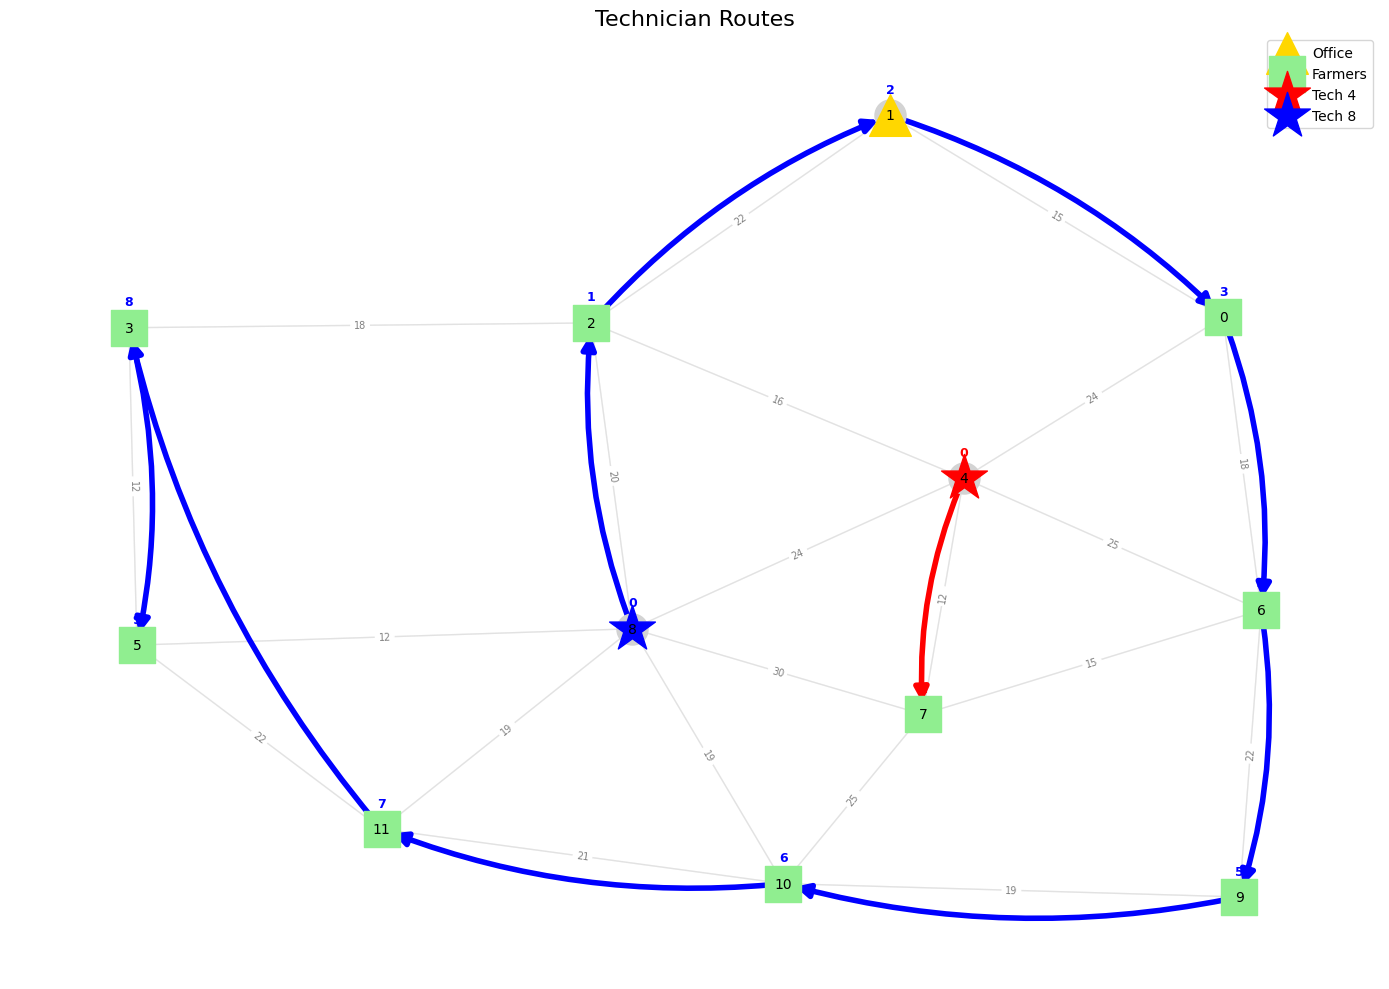

In [15]:
plot_routes(all_nodes, distance, routes, technicians, office_node, farmers)

In [18]:
farmers = [1, 2, 3, 6, 7, 9, 10, 11]
technicians = [0, 4, 5]

initial_straws = {
    0: 1,
    4: 1,
    5: 1
}

total_straws_available = 15

office_node = 8
offices = [8]

all_nodes = list(range(full_distance.shape[0]))

technician_origin = {
    tech: tech
    for tech in technicians
}

routes = solve_technician_routing(
    all_nodes=all_nodes,
    farmers=farmers,
    technicians=technicians,
    office_node=office_node,
    initial_straws=initial_straws,
    total_straws_available=total_straws_available,
    full_distance=full_distance,
    origin_of=technician_origin,
    time_limit=None,
    verbose=False
)

print(routes)

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 1155 rows, 939 columns and 5121 nonzeros (Min)
Model fingerprint: 0x72176be0
Model has 396 linear objective coefficients
Variable types: 432 continuous, 507 integer (468 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+06]
  Objective range  [1e+01, 7e+01]
  Bounds range     [1e+00, 2e+01]
  RHS range        [1e+00, 1e+06]

Presolve removed 47 rows and 86 columns
Presolve time: 0.07s
Presolved: 1108 rows, 853 columns, 7712 nonzeros
Variable types: 396 continuous, 457 integer (421 binary)

Root relaxation: objective 1.870000e+02, 264 iterations, 0.02 seconds (0.01 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Ti

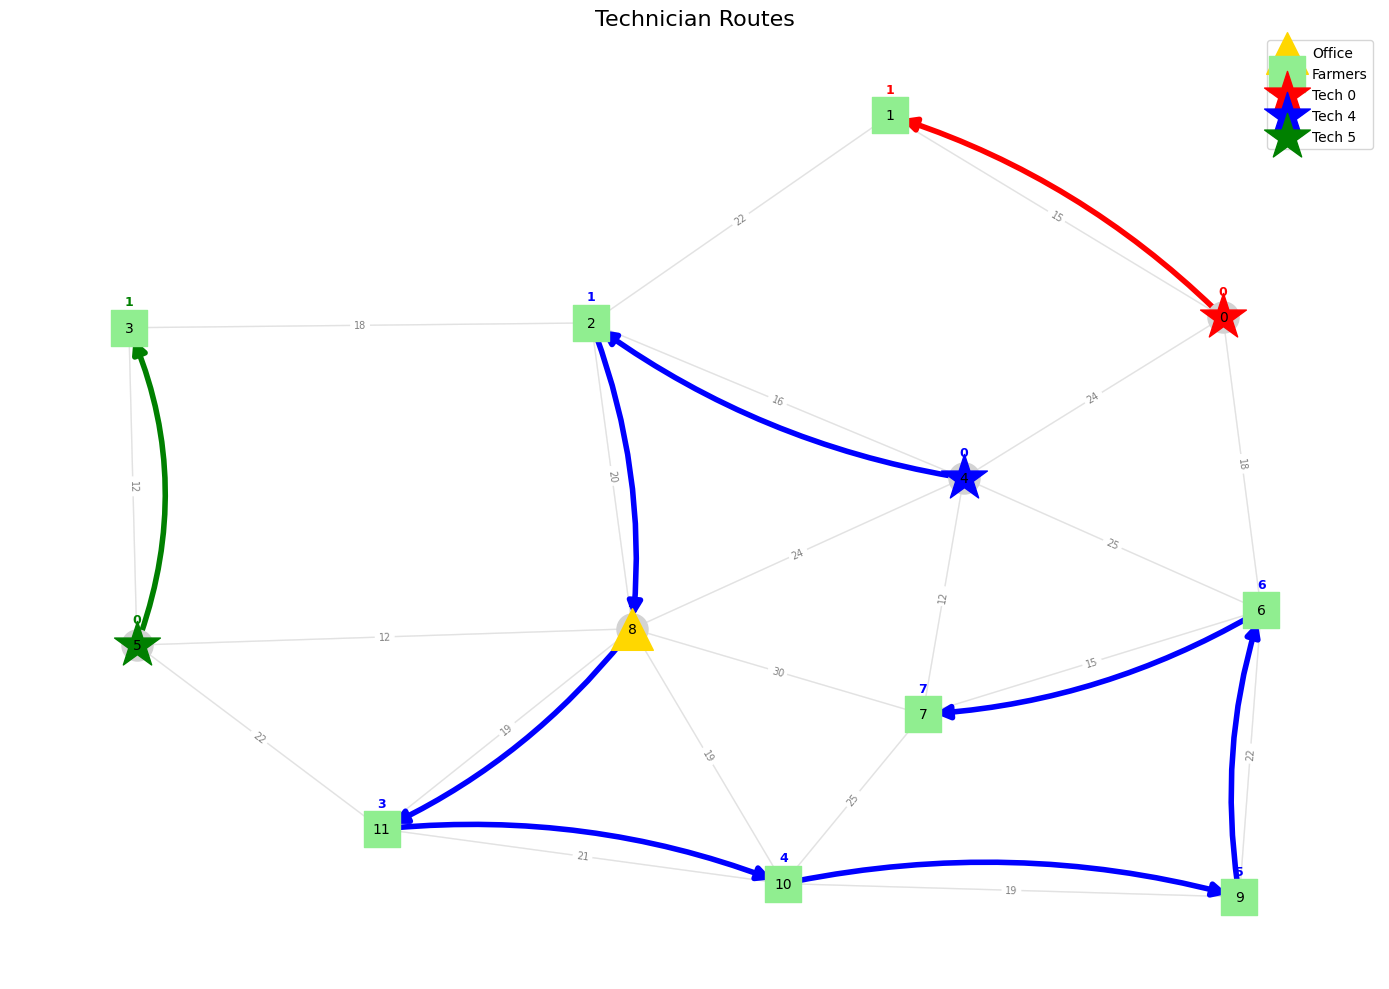

In [19]:
plot_routes(all_nodes, distance, routes, technicians, office_node, farmers)